# Forest Cover Type Classification

The exercises on this sheet are graded by a maximum of **17** points. You will be asked to implement several functions.

Team work is not allowed. Everybody implements his/her own code. Discussing issues with others is fine, sharing code with others is not.

If you use any code fragments found on the Internet, make sure you reference them properly.

In this exercise, we will **predict the forest cover type** (the predominant kind of tree cover) from strictly cartographic variables. 

As in the regression assignment, $Y$ stands for a column vector of "target" values, that is the $i$-th row of $Y$ contains the desired output for the $i$-th data point. Contrary to regression, the elements of $Y$ in this classification task are integer values.

We will work with several popular classifiers provided by Scikit-learn package.

## Dataset: Forest cover data
This dataset contains 581012 tree observations from four areas of the Roosevelt National Forest in Colorado. All observations are cartographic variables (no remote sensing) from 30 meter x 30 meter sections of forest. 

This dataset includes information on tree type, shadow coverage, distance to nearby landmarks (roads etcetera), soil type, and local topography.

### Data Dictionary
- Elevation = Elevation in meters.
- Aspect = Aspect in degrees azimuth.
- Slope = Slope in degrees.
- Horizontal_Distance_To_Hydrology = Horizontal distance to nearest surface water features.
- Vertical_Distance_To_Hydrology = Vertical distance to nearest surface water features.
- Horizontal_Distance_To_Roadways = Horizontal distance to nearest roadway.
- Hillshade_9am = Hill shade index at 9am, summer solstice. Value out of 255.
- Hillshade_Noon = Hill shade index at noon, summer solstice. Value out of 255.
- Hillshade_3pm = Hill shade index at 3pm, summer solstice. Value out of 255.
- Horizontal_Distance_To_Fire_Points = sHorizontal distance to nearest wildfire ignition points.
- Wilderness_Area1 = Rawah Wilderness Area
- Wilderness_Area2 = Neota Wilderness Area
- Wilderness_Area3 = Comanche Peak Wilderness Area
- Wilderness_Area4 = Cache la Poudre Wilderness Area
- Soil_Type1 to Soil_Type40 (Total 40 Types)
- **Cover_Type** = Forest Cover Type designation. Integer value between 1 and 7, with the following key:

    1. Spruce/Fir
    2. Lodgepole Pine
    3. Ponderosa Pine
    4. Cottonwood/Willow
    5. Aspen
    6. Douglas-fir
    7. Krummholz



## Objective: 

We will **predict different cover types** in different wilderness areas of the Roosevelt National Forest of Northern Colorado with the best accuracy.

## Content:

1) Load Data (1 point)

2) Basic Statistics (1 point)

3) Exploratory Data Analysis (2 points)

4) Training Models (1 point)

    a) Logistic Regression (1 point)

    b) Decision Tree Classifier (1 point)

    c) Random Forest (1 point)

    d) K Nearest Neighbor (1 point)
    
    x) Grid Search (Optional)

    e) Support Vector Machine (Optional - Highly recommended if your computer is powerful enough)
    
    x) Comment (1 point)

5) Data Imbalance Problem

    a) Training with Under-Sampled Data (3 points)

    b) Training with Over-Sampled Data (3 points)
    
    x) Comment (1 point)

In [1]:
# import packages
import pandas as pd
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

## 1) Load data
- Download the dataset from: https://drive.google.com/file/d/1zmAtaGQzIz2odciyqBc8mJHelBIcbsGV/view?usp=sharing
- Use ```pd.read_csv()``` to load the data, without any arguments.

In [2]:
df = pd.read_csv('Datasets/ForestCover.csv')

- Visualize the first and the last 5 rows of the data.

In [3]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [4]:
df.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3
581011,2383,165,13,60,4,67,231,244,141,875,...,0,0,0,0,0,0,0,0,0,3


## 2) Basic statistics
- Print overall information of the data frame.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

- Print dataframe statistics (mean, std, etc.).

In [6]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


- Check if there are missing values. If yes, drop them.

In [7]:
# Check if there are missing values
df.isna().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


## 3) Exploratory Data Analysis
- Show the category distribution for the target data.

In [8]:
df['Cover_Type'].value_counts()

2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: Cover_Type, dtype: int64

- Visulize the target distribution.

<AxesSubplot: >

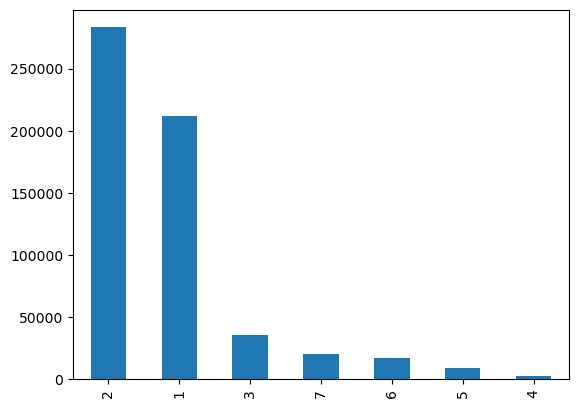

In [9]:
df['Cover_Type'].value_counts().plot(kind='bar')

### Feature Histograms 
- Visulize data distribution of the first four features via histograms. (Show four figures.)

<AxesSubplot: ylabel='Frequency'>

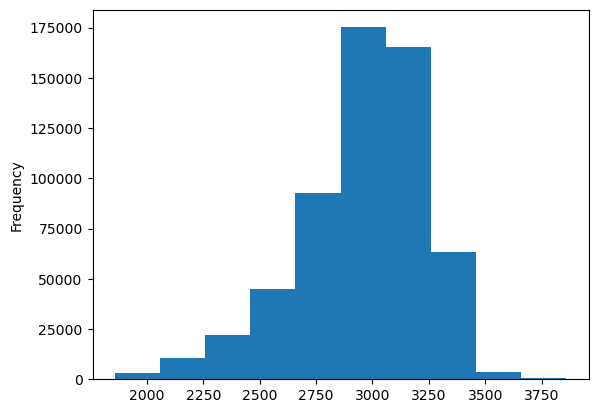

In [10]:
df['Elevation'].plot(kind='hist')

<AxesSubplot: ylabel='Frequency'>

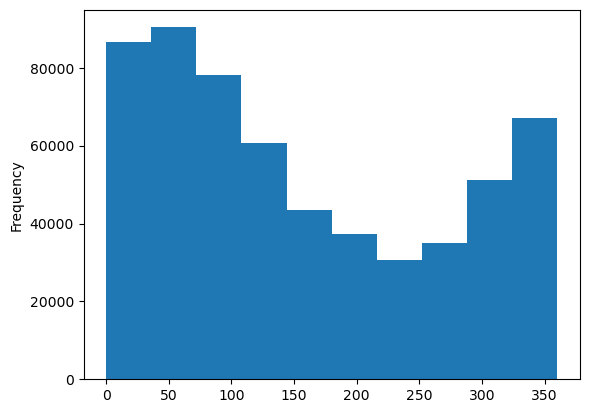

In [11]:
df['Aspect'].plot(kind='hist')

<AxesSubplot: ylabel='Frequency'>

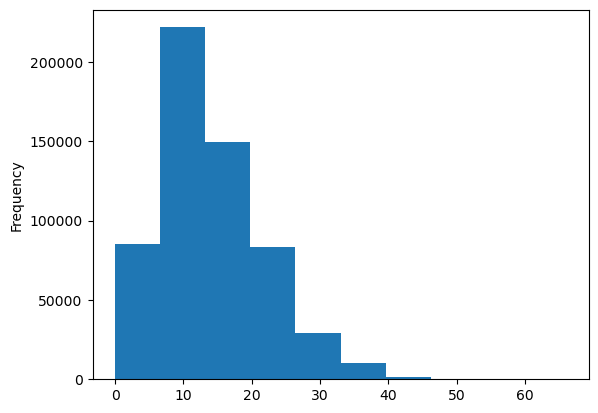

In [12]:
df['Slope'].plot(kind='hist')

<AxesSubplot: ylabel='Frequency'>

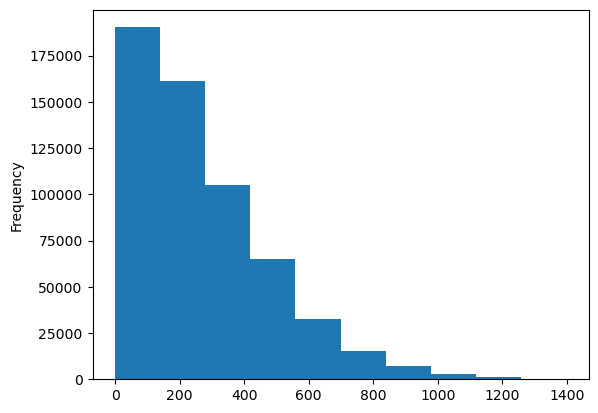

In [13]:
df['Horizontal_Distance_To_Hydrology'].plot(kind='hist')


### Correlation between Variables
- Show correlation between variables. (Since 55 columns are too many, please show here a 10x10 heatmap for the first 10 features.）

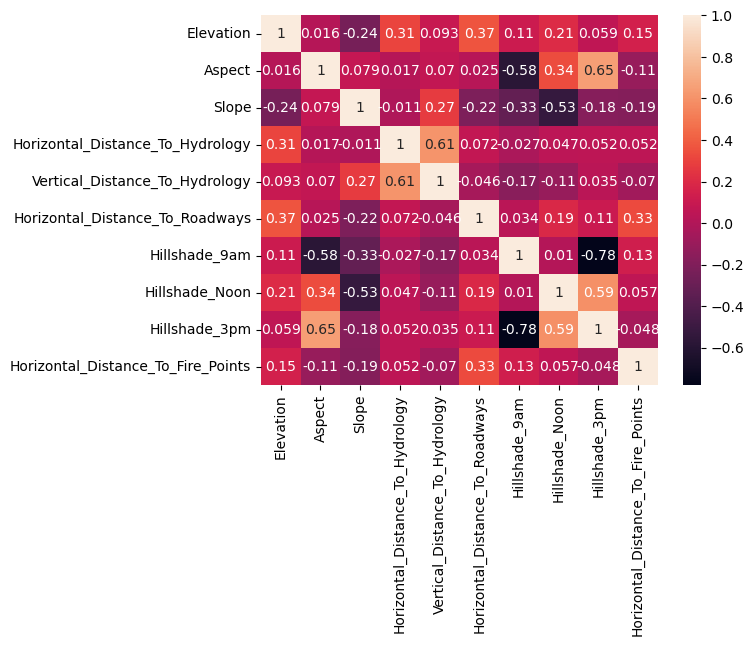

In [14]:
df_first10 = df.iloc[:, :10]
sns.heatmap(df_first10.corr(), annot=True)
plt.show()

### Data Distribution w.r.t. Categories
- Show data distribution w.r.t. categories via boxplots. (x-axis: cover type, y-axis: feature variable, please show 10 figures for the first 10 variables.)

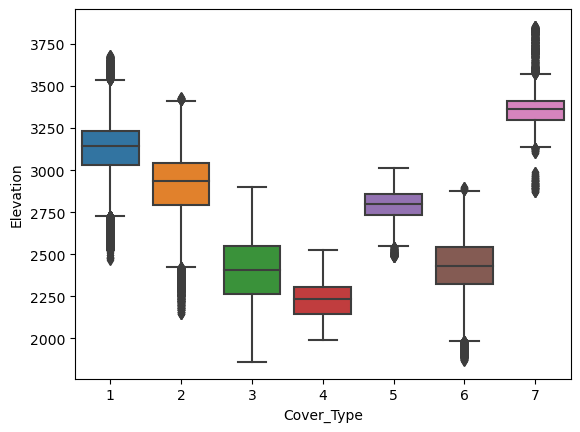

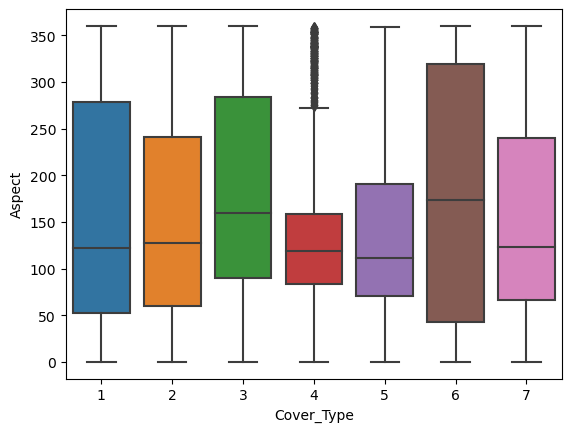

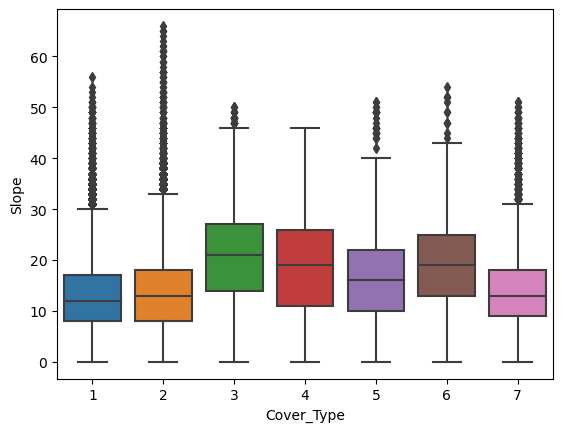

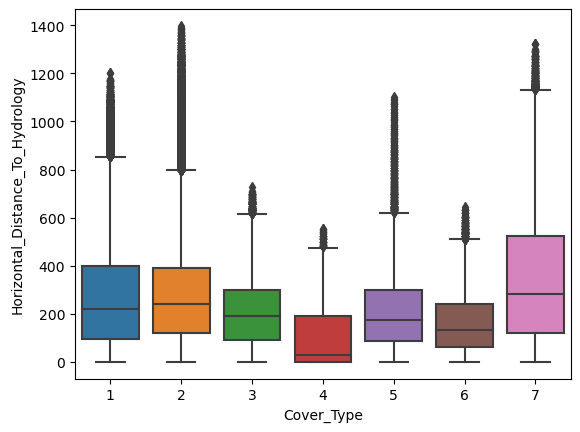

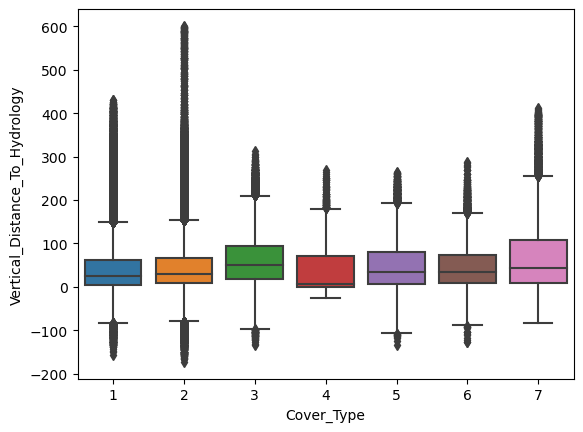

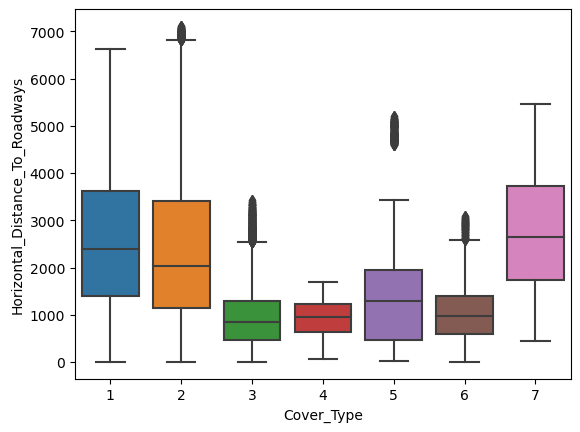

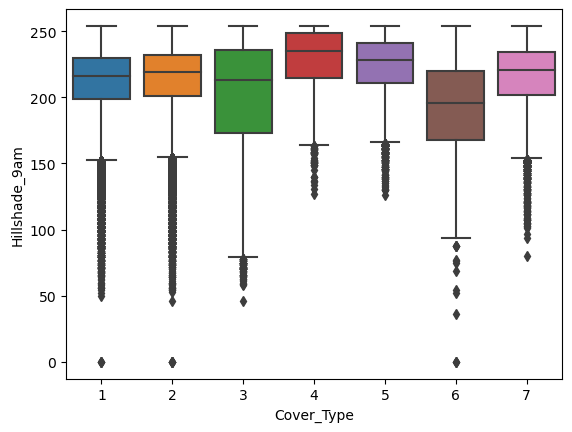

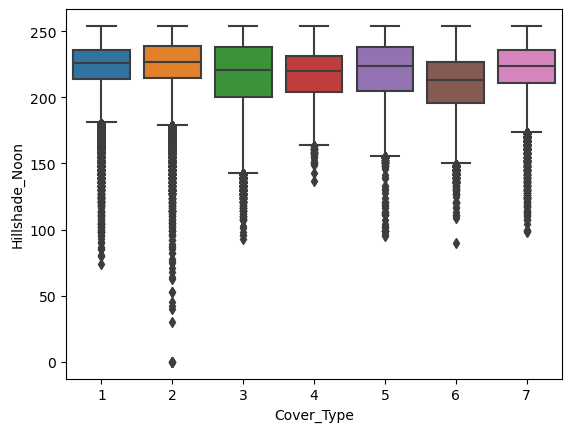

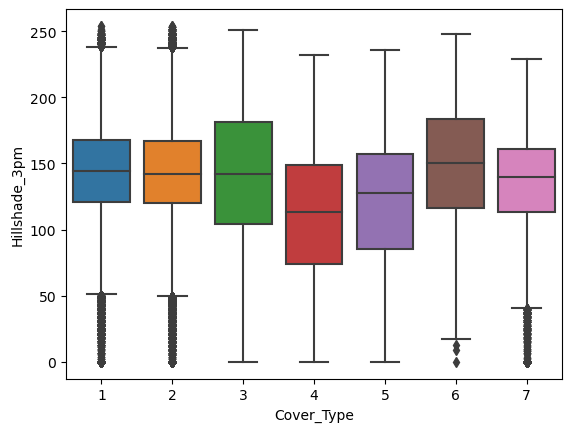

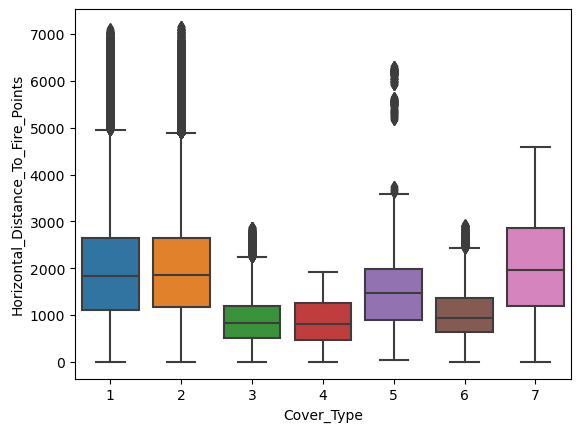

In [15]:
# df.boxplot(column=['Elevation'], by='Cover_Type')
for y in df.iloc[:, :10].columns:
    sns.boxplot(data=df, x='Cover_Type', y=y)
    plt.show()

- Are there any features which shows not much of variance with respect to classes? Which ones?

ANSWER: Considering the variation of the size of the boxes, I would say that the following features show very much variance w.r.t. the class:
- Aspect
- Horizontal_Distance_To_Roadways
- Hillshade_9am

And the rest of features shows not much variance.

- Which features might do good job in the prediction?

ANSWER:
- Horizontal_Distance_To_Hydrology      
- Vertical_Distance_To_Hydrology
- Hillshade_Noon

## 4) Training Models

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

- Define Feature (X) and Target (y)

In [17]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

- Splitting the data into train and test.

    Split the data into train and test with test size and 30% and train size as 70%, use a random seed.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Training data size:',X_train.shape)
print('Test data size:',X_test.shape)

Training data size: (406708, 54)
Test data size: (174304, 54)


- Normalize the data.

In [19]:
sc = StandardScaler()
x_train = sc.fit_transform(X_train)
x_test = sc.transform(X_test)

### 4a) Logistic Regression
- Train the Logistic Regression model (See: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

Suggestion: 
- Please use the setting n_jobs=-1 for exploiting all of the cores if it is taken by the model.
- For the logitic regression, You can use the settings solver='liblinear'  -- takes a few minutes
- For the logitic regression, solver='sag' or 'saga' -- takes less time but the results are worse (if your computer cannot solve in a few minutes, please utilize this solver.)
- If it still takes too much time:
    - Use only first 10 columns of the dataset 
    - Don't forget to use the same settings for all the models

In [20]:
%%time
# Train the model (only training)
lr = LogisticRegression()
lr.fit(X_train, y_train)

CPU times: total: 2min
Wall time: 20.5 s


c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

- Predict on the test data

In [21]:
%%time
# Test the model
lr.predict(x_test)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\base.py:409: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


CPU times: total: 219 ms
Wall time: 39 ms


array([3, 3, 2, ..., 3, 2, 3], dtype=int64)

- Compute and print performance metrics, using ```accuracy_score()```: the fraction of correctly classified samples.

In [22]:
%%time
accuracy_score(y_test, lr.predict(x_test))

CPU times: total: 281 ms
Wall time: 45 ms


c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\base.py:409: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.2613365155131265

### 4b) Decision Tree Classifier
- Train and test with decision tree classifier
- Print the accuracy

In [23]:
%%time
# Train the model (only training)
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

CPU times: total: 7.05 s
Wall time: 6.86 s


DecisionTreeClassifier()

In [24]:
%%time
# Test the model
dt.predict(x_test)

CPU times: total: 62.5 ms
Wall time: 77 ms


array([1, 2, 2, ..., 2, 2, 2], dtype=int64)

### 4c) Random Forest
- Train and test with decision tree classifier
- Print the accuracy

In [25]:
%%time
# Train the model (only training)
rf = RandomForestClassifier(max_depth=2, random_state=0)
rf.fit(x_train, y_train)

CPU times: total: 11.2 s
Wall time: 11.4 s


RandomForestClassifier(max_depth=2, random_state=0)

In [26]:
%%time
# Test the model
rf.predict(x_test)

CPU times: total: 1.2 s
Wall time: 1.21 s


array([1, 2, 2, ..., 2, 2, 2], dtype=int64)

### 4d) K Nearest Neighbor
- Train and test with KNN classifier
- Print the accuracy

(It might take a bit long, around an hour if using one cpu core.)

In [27]:
%%time
# Train the model (only training)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

CPU times: total: 141 ms
Wall time: 134 ms


KNeighborsClassifier(n_neighbors=3)

In [28]:
%%time
# Test the model
knn.predict(x_test)

CPU times: total: 10min 15s
Wall time: 1min


array([1, 2, 2, ..., 2, 2, 2], dtype=int64)

### Hyperparameter Tuning (OPTIONAL)

Let's search a better K (e.g. among candidates \[3,5,11\]) for the KNN classifier, using ```GridSearchCV()```.


In [29]:
# from sklearn.model_selection import GridSearchCV

- define parameter candidates and grid search

In [30]:
# tree_para = {'n_neighbors':[3,5,11]}

- fit the model wtih all grid parameters

In [31]:
# knn_grid = GridSearchCV(KNeighborsClassifier(), tree_para, cv=5)
# knn = knn_grid.fit(x_train, y_train)

- print the best K.

In [32]:
# knn.best_params_

- print the test accuracy with this K.

In [33]:
# knn.best_score_

### 4e) Support Vector Machine (OPTIONAL)
- Train and test with SVM classifier
- Print the accuracy

(It might take a bit long, around 3 hours if using one cpu core...)

In [34]:
%%time
# Train the model (only training)
# model_svm = svm.SVC(kernel='linear', C=1.0)
# model_svm.fit(x_train, y_train)

CPU times: total: 0 ns
Wall time: 0 ns


In [35]:
%%time
# Test the model
# model_svm.predict(x_test)

CPU times: total: 0 ns
Wall time: 0 ns


### Conclusion (Graded)
- Please write your conclusion:

ANSWER: In this exercise we build several ML models using different popular algorithms, namely, logistic regression, decision tree, random forest, and k nearst neighbor for classification problem. We predict the cover type (categorical data) using normalized training data. We found that decision tree shows the best performance with the accuracy of 0.934, whereas the logistic regression is the least accurate with the accuracy of 0.261. Moreover, KNN also shows a good performance whose accuracy is a bit lower than that of decision tree. In additionm hyperparameters also play an important role in the performance of the ML algorithms, especially when the data becomes more large and complicated. Therefore, search of the best hyperparameter is important and essential.

In [36]:
acc1 = accuracy_score(y_test, lr.predict(x_test))
acc2 = accuracy_score(y_test, dt.predict(x_test))
acc3 = accuracy_score(y_test, rf.predict(x_test))
acc4 = accuracy_score(y_test, knn.predict(x_test))
print(acc1)
print(acc2)
print(acc3)
print(acc4)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\base.py:409: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.2613365155131265
0.9339200477326969
0.5773074628235726
0.9290779328070498


Accuracy score (Graded):
- Logistic Regression: 0.2613365155131265
- Decision Tree: 0.9339544703506517
- Random Forest: 0.5773074628235726
- K Nearest Neighbor: 0.9290779328070498
- K Nearest Neighbor after hypertuning K (optional):
- Support Vector Machine (optional): 

Let's go deeper.
## 5) Data imbalance problem

An imbalanced classification problem is an example of a classification problem where the distribution of examples across the known classes is biased or skewed. The distribution can vary from a slight bias to a severe imbalance where there is one example in the minority class for hundreds, thousands, or millions of examples in the majority class or classes.

Imbalanced classifications pose a challenge for predictive modeling as most of the machine learning algorithms used for classification were designed around the assumption of an equal number of examples for each class. This results in models that have poor predictive performance, specifically for the minority class. This is a problem because typically, the minority class is more important and therefore the problem is more sensitive to classification errors for the minority class than the majority class.

Here you can change the dataset that you use to build your predictive model to have more balanced data.

This change is called sampling your dataset and there are two main methods that you can use to even-up the classes:

- 1) You can add copies of instances from the under-represented class called over-sampling (or more formally sampling with replacement); 
- 2) or you can delete instances from the over-represented class, called under-sampling.

Please train Randome Forest classifiers with both under-sampled data and over-sampled data, and compare their accuracy scores.

As we have seen in 3), the data is imbalanced.

### 5a) Training with under-sampled data

- print the size of the smallest class

In [37]:
min_class_size = df['Cover_Type'].value_counts().min()
print("Size of smallest class: ", min_class_size)

Size of smallest class:  2747


- Undersample all the majority classes so that all classes has the same smallest cardinality.

Suggested Steps:
1) Subsets for each class, using .query()
2) Downsample each subset, using .sample()
3) Concatenate the seven subsets, using .concat(), 
4) Shuffle the data, using .sample() on the full set

Second Option:
- Use a for-loop to iterate the target values, use .unique()
- For each target value, take the samples whose target = the certain target
- Sample from this subset and append in a list
- Concatenate the list

In [38]:
from collections import Counter
from imblearn.under_sampling import NearMiss

# summarize class distribution
counter = Counter(y)
print(counter)
# define the undersampling method
undersample = NearMiss(version=1, n_neighbors=3)
# transform the dataset
X_under, y_under = undersample.fit_resample(X, y)

Counter({2: 283301, 1: 211840, 3: 35754, 7: 20510, 6: 17367, 5: 9493, 4: 2747})


- check the class distribution of the undersampled data

<AxesSubplot: >

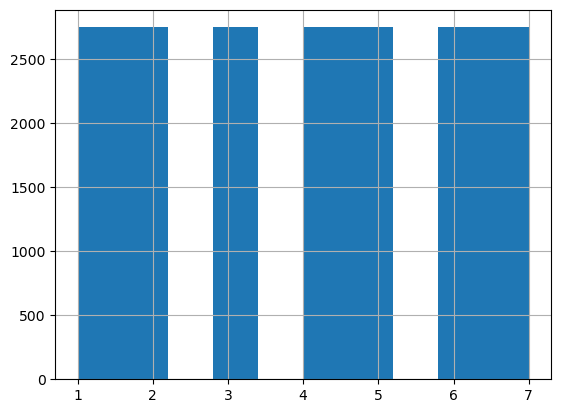

In [39]:
y_under.hist()

- Preprocessing data (define X, y; train test split; normalize data)

In [40]:
X_under_train, X_under_test, y_under_train, y_under_test = train_test_split(X_under, y_under, test_size=0.3, random_state=42)

# Normalize the data
sc = StandardScaler()
X_under_train = sc.fit_transform(X_under_train)
X_under_test = sc.transform(X_under_test)

print('Training undersampled data size:',X_under_train.shape)
print('Test undersampled data size:',X_under_test.shape)

Training undersampled data size: (13460, 54)
Test undersampled data size: (5769, 54)


- Train and test random forest classifier on under-sampled data
- Print the accuracy

In [41]:
%%time
# Train
rf = RandomForestClassifier(max_depth=2, random_state=0)
rf.fit(X_under_train, y_under_train)

CPU times: total: 406 ms
Wall time: 420 ms


RandomForestClassifier(max_depth=2, random_state=0)

In [42]:
%%time
# Test
rf.predict(X_under_test)

CPU times: total: 46.9 ms
Wall time: 39 ms


array([1, 5, 7, ..., 4, 4, 3], dtype=int64)

In [43]:
accuracy_score(y_under_test, rf.predict(X_under_test))

0.5562489166233316

### 5b) Training with over-sampled data

- print the size of the largest class

In [44]:
max_class_size = df['Cover_Type'].value_counts().max()
print("Size of largest class: ", max_class_size)

Size of largest class:  283301


- Oversample the classes. (Don't forget to use replace=True in sampling)

In [45]:
from imblearn.over_sampling import RandomOverSampler

# summarize class distribution
counter = Counter(y)
print(counter)
# define oversampling strategy
oversample = RandomOverSampler(sampling_strategy='minority')
# fit and apply the transform
X_over, y_over = oversample.fit_resample(X, y)

Counter({2: 283301, 1: 211840, 3: 35754, 7: 20510, 6: 17367, 5: 9493, 4: 2747})


- check the class distribution of the oversampled data

<AxesSubplot: >

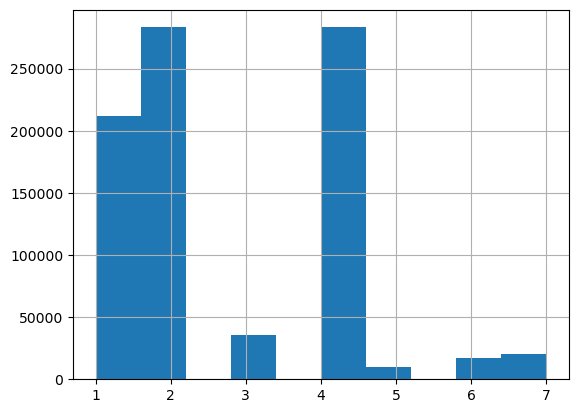

In [46]:
y_over.hist()

- Preprocessing data (define X, y; train test split; normalize data)

In [47]:
X_over_train, X_over_test, y_over_train, y_over_test = train_test_split(X_over, y_over, test_size=0.3, random_state=42)

# Normalize the data
sc = StandardScaler()
X_over_train = sc.fit_transform(X_over_train)
X_over_test = sc.transform(X_over_test)

print('Training oversampled data size:',X_over_train.shape)
print('Test oversampled data size:',X_over_test.shape)

Training oversampled data size: (603096, 54)
Test oversampled data size: (258470, 54)


- Train and test random forest classifier on over-sampled data
- Print the accuracy

In [48]:
%%time
# Train
rf = RandomForestClassifier(max_depth=2, random_state=0)
rf.fit(X_over_train, y_over_train)

CPU times: total: 19 s
Wall time: 19.6 s


RandomForestClassifier(max_depth=2, random_state=0)

In [49]:
%%time
# Test
rf.predict(X_over_test)

CPU times: total: 1.72 s
Wall time: 1.76 s


array([4, 4, 2, ..., 4, 2, 2], dtype=int64)

In [50]:
accuracy_score(y_over_test, rf.predict(X_over_test))

0.6548148721321624

#### Conclusion on imbalanced data solution (with random forest classifier):
Accuracy:

- imbalanced data: 0.5773074628235726
- undersampled data: 0.5562489166233316
- oversampled data: 0.6548148721321624

Which sampling method works the best? Why?

ANSWER: Oversampling is better because there is no loss of data. (data loss in undersampling)